In [1]:
import pandas as pd

from src.configuration.config import set_seed
from src.AggregationBasedArchitecture.Logistic_Regression import LogReg_all_signals

In [2]:
BASE_SEED = 42
set_seed(BASE_SEED)

In [3]:
dfSimAgg = pd.read_csv("../data/aggregated/simAgg.csv")
dfAdvAgg = pd.read_csv("../data/aggregated/advAgg.csv")

# Simple Aggregation

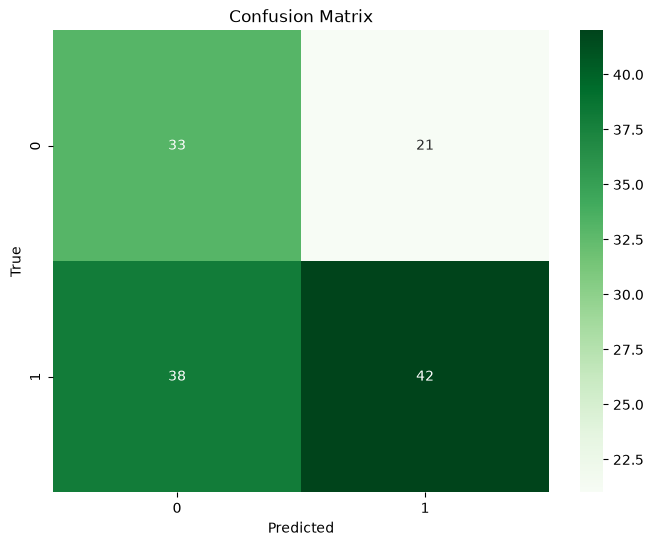

In [4]:
results = []
results = LogReg_all_signals(dfSimAgg, results, "Simple")

# Advanced Aggregation

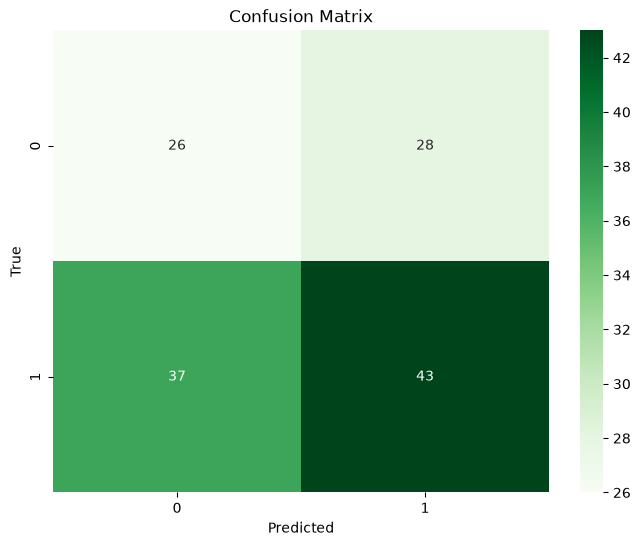

In [5]:
results = LogReg_all_signals(dfAdvAgg, results, "Advanced")

# Overview over both Experiments

In [6]:
summary = pd.DataFrame(results)
summary["macro_f1"] = (summary["f1_0"] + summary["f1_1"]) / 2

summary = summary.sort_values("Accuracy (Balanced)", ascending=False).round(3)

In [7]:
summary

,Aggregation,Accuracy (Balanced),Loss,precision_0,precision_1,recall_0,recall_1,f1_0,f1_1,macro_f1
0,Simple,0.568,0.744,0.465,0.667,0.611,0.525,0.528,0.587,0.558
1,Advanced,0.509,0.842,0.413,0.606,0.481,0.538,0.444,0.570,0.507


# Converting To LaTeX

In [8]:
summary.to_latex(
    "../results/logistic_regression/tables/model_results.tex",
    index=True,
    float_format="%.3f"
)